In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [2]:
# --- 1. Setup ---
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
DATA_PATH = '/content/local_data' # Updated to use local data for faster I/O

In [3]:
# Create a local folder on the fast SSD
!mkdir -p /content/local_data

# Copy the merged data from Drive to the local runtime (this takes a few mins)
print("Copying data to local storage for faster training...")
!cp -r /content/drive/MyDrive/FYP/merged_data/* /content/local_data/

# NOW update your DATA_PATH in your CNN code:
# DATA_PATH = '/content/local_data'

Copying data to local storage for faster training...


In [4]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("GPU Name: ", tf.test.gpu_device_name())

Num GPUs Available:  1
GPU Name:  /device:GPU:0


In [5]:
# --- 2. Advanced Data Augmentation ---
# Note: We use specific preprocessing for DenseNet
datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.densenet.preprocess_input,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(DATA_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', subset='training')
val_gen = datagen.flow_from_directory(DATA_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', subset='validation', shuffle=False)


Found 7264 images belonging to 5 classes.
Found 1814 images belonging to 5 classes.


In [6]:
# --- 3. Model Architecture (DenseNet121) ---
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(512, activation='relu'),
    layers.Dense(5, activation='softmax')
])

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
# --- 4. Callbacks for 90%+ Accuracy ---
# Stops training if validation loss stops improving to prevent overfitting
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, min_delta=1e-4)
# Reduces learning rate when the model plateaus
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7)

In [8]:
# --- 5. Training Stage 1 & 2 ---
model.compile(optimizer=optimizers.Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
print("Phase 1: Warming up head...")
history1 = model.fit(train_gen, validation_data=val_gen, epochs=10, callbacks=[early_stop, reduce_lr])

print("Phase 2: Fine-tuning entire model...")
base_model.trainable = True # Unfreeze all layers of the base model
# No layers are explicitly frozen here, allowing all to be fine-tuned

model.compile(optimizer=optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
history2 = model.fit(train_gen, validation_data=val_gen, epochs=50, callbacks=[early_stop, reduce_lr]) # Increased epochs for more training opportunity

Phase 1: Warming up head...
Epoch 1/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 184s 664ms/step - accuracy: 0.4316 - loss: 1.4330 - val_accuracy: 0.4509 - val_loss: 1.2395 - learning_rate: 0.0010
Epoch 2/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 127s 558ms/step - accuracy: 0.4799 - loss: 1.2321 - val_accuracy: 0.5634 - val_loss: 1.2266 - learning_rate: 0.0010
Epoch 3/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 125s 552ms/step - accuracy: 0.5100 - loss: 1.1554 - val_accuracy: 0.4961 - val_loss: 1.2914 - learning_rate: 0.0010
Epoch 4/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 126s 555ms/step - accuracy: 0.5240 - loss: 1.1334 - val_accuracy: 0.5176 - val_loss: 1.2818 - learning_rate: 0.0010
Epoch 5/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 126s 556ms/step - accuracy: 0.5219 - loss: 1.1210 - val_accuracy: 0.5678 - val_loss: 1.2476 - learning_rate: 0.0010
Epoch 6/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 126s 556ms/step - accuracy: 0.5445 - loss: 1.0809 - val_accuracy: 0.5722 - val_loss: 1.1924 - learning_rate: 2.0000e-04
Epoch 7/10
227/227 ━━━━━━━━━━━━━

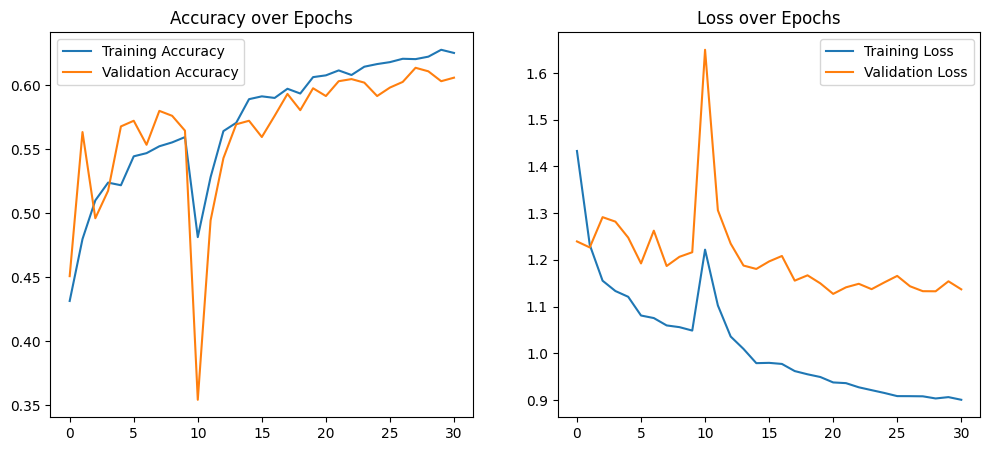

In [9]:
# --- 6. VISUALIZATIONS ---

def plot_history(h1, h2):
    acc = h1.history['accuracy'] + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss = h1.history['loss'] + h2.history['loss']
    val_loss = h1.history['val_loss'] + h2.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.legend()
    plt.show()

plot_history(history1, history2)

57/57 ━━━━━━━━━━━━━━━━━━━━ 51s 681ms/step


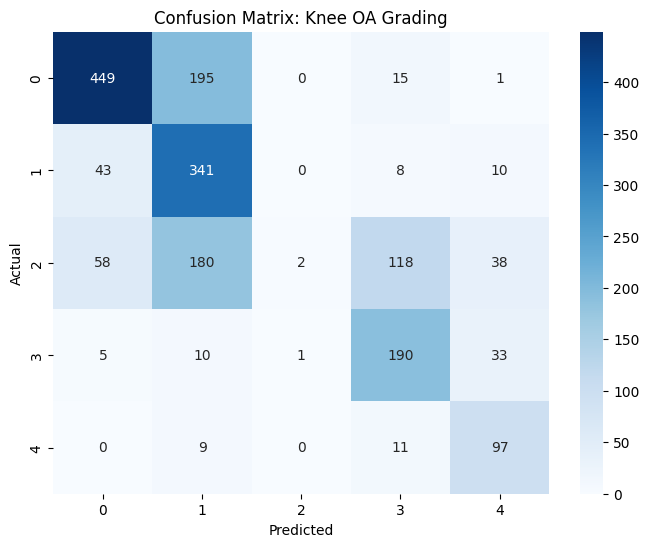

In [10]:
# --- 7. CONFUSION MATRIX ---
Y_pred = model.predict(val_gen)
y_pred = np.argmax(Y_pred, axis=1)
cm = confusion_matrix(val_gen.classes, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['0','1','2','3','4'], yticklabels=['0','1','2','3','4'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Knee OA Grading')
plt.show()

In [12]:
# Change the extension from .h5 to .keras
model_save_path = '/content/drive/MyDrive/FYP/CNN.-Final.keras'
model.save(model_save_path)

print(f"Model successfully saved as a native Keras file at: {model_save_path}")

Model successfully saved as a native Keras file at: /content/drive/MyDrive/FYP/CNN.-Final.keras
